The aim of this notebook is to generate option chains in order to test different models.

Here are different specifications of what we want it to look like:

* The output must be a CSV file in which we'll have an option chain of each day for call and put 
* Maturities must be chosen as an input of the code
* Strikes also need to be chosen as an input of the model

For the inputs we need:


For the outputs, we want:

at each line of our csv file strike price, direction (call or put), volatility, all the greeks, bid/ask price of the option


In [3]:
# here are all the inputs needed:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

Because we want a volatility surface and a visualize the skew, let's consider the Heston Model:

# 1. Let's simulate the path with the Heston model:

# The Heston Stochastic Volatility Model

The Heston model is one of the most widely used stochastic volatility models in quantitative finance. Introduced by Steven Heston in 1993, it extends the Black–Scholes framework by allowing the instantaneous variance of the underlying asset to evolve randomly over time. This enables the model to reproduce important market phenomena such as the implied volatility smile and skew.

Under the risk-neutral probability measure $\mathbb{Q}$, the dynamics of the asset price $S_t$ and its instantaneous variance $v_t$ are given by

$$
\begin{aligned}
dS_t &= (r-q)S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S, \\
dv_t &= \kappa(\theta-v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v,
\end{aligned}
$$

where

$$
dW_t^S\,dW_t^v=\rho\,dt.
$$

The model parameters are:

- $r$: continuously compounded risk-free interest rate.
- $q$: continuous dividend yield.
- $v_t$: instantaneous variance.
- $\theta$: long-term mean level of the variance.
- $\kappa$: speed of mean reversion.
- $\xi$: volatility of volatility (vol-of-vol).
- $\rho$: correlation between the asset price and variance Brownian motions.

The variance process follows a Cox–Ingersoll–Ross (CIR) process, ensuring positivity under suitable parameter conditions. In particular, the **Feller condition**

$$
2\kappa\theta \geq \xi^2
$$

guarantees that the variance remains strictly positive.

The parameter $\rho$ plays a crucial role in reproducing the volatility skew observed in equity markets. A negative correlation implies that downward movements in the asset price are typically accompanied by increases in volatility, a phenomenon commonly referred to as the *leverage effect*.

The infinitesimal covariance matrix of the two-dimensional diffusion is

$$
\Sigma(v_t)=
\begin{pmatrix}
v_tS_t^2 & \rho\xi v_tS_t \\
\rho\xi v_tS_t & \xi^2v_t
\end{pmatrix}.
$$

Applying Itô's lemma to the logarithm of the asset price yields

$$
d\ln S_t
=
\left(r-q-\frac{v_t}{2}\right)dt
+
\sqrt{v_t}\,dW_t^S.
$$

Unlike the Black–Scholes model, the Heston model does not admit a closed-form expression for the option price itself. However, Heston derived a semi-analytical solution based on the characteristic function of the log-price. The value of a European call option with strike $K$ and maturity $T$ is

$$
C(S_0,K,T)
=
S_0e^{-qT}P_1
-
Ke^{-rT}P_2,
$$

where $P_1$ and $P_2$ are risk-neutral probabilities obtained through Fourier inversion of the characteristic function of $\ln(S_T)$.

The characteristic function can be written as

$$
\phi(u)
=
\mathbb{E}^{\mathbb{Q}}
\left[
e^{iu\ln(S_T)}
\right]
=
\exp\left(
C(u,T)
+
D(u,T)v_0
+
iu\ln(S_0)
\right),
$$

where the functions $C(u,T)$ and $D(u,T)$ admit explicit analytical expressions. This representation makes the Heston model particularly suitable for efficient numerical pricing using Fourier transform techniques such as the Carr–Madan method or the COS method.

The Heston model has become a standard benchmark in equity, FX, and commodity derivatives markets due to its ability to capture stochastic volatility while remaining computationally tractable. Its characteristic-function formulation also makes it highly suitable for calibration to market option prices.

In [1]:
def generate_heston_paths(S, T, r, kappa, theta, v_0, rho, xi, steps, Npaths, return_vol=False):
    dt = T/steps
    size = (Npaths, steps)
    prices = np.zeros(size)
    sigs = np.zeros(size)
    S_t = S
    v_t = v_0
    for t in range(steps):
        WT = np.random.multivariate_normal(np.array([0,0]), cov = np.array([[1,rho],[rho,1]]),size=Npaths) * np.sqrt(dt) 
        
        S_t = S_t*(np.exp( (r- 0.5*v_t)*dt+ np.sqrt(v_t) *WT[:,0] ) )
        v_t = np.abs(v_t + kappa*(theta-v_t)*dt + xi*np.sqrt(v_t)*WT[:,1])
        prices[:, t] = S_t
        sigs[:, t] = v_t
    
    if return_vol:
        return prices, sigs
    
    return prices

Text(0, 0.5, 'Density')

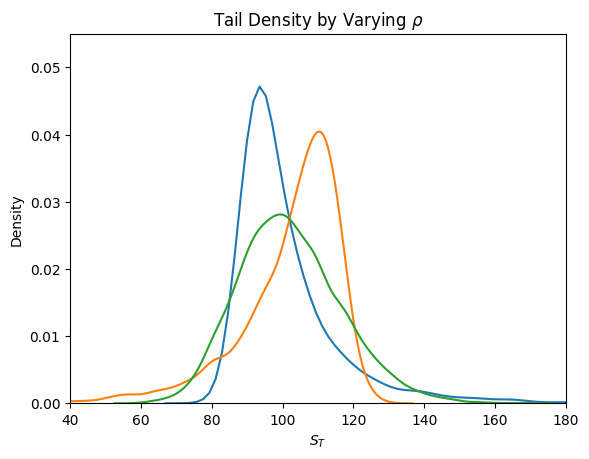

In [5]:
kappa =4
theta = 0.02
v_0 =  0.02
xi = 0.9
r = 0.02
S = 100
paths =5000
steps = 2000
T = 1

prices_pos = generate_heston_paths(S, T, r, kappa, theta,
                                    v_0, rho=0.9, xi=xi, steps=steps, Npaths=paths,
                                    return_vol=False)[:,-1]  
prices_neg  = generate_heston_paths(S, T, r, kappa, theta,
                                    v_0, rho=-0.9, xi=xi, steps=steps, Npaths=paths,
                                    return_vol=False)[:,-1]       
gbm_bench = S*np.exp( np.random.normal((r - v_0/2)*T , 
                                np.sqrt(theta)*np.sqrt(T), size=paths))

fig, ax = plt.subplots()

ax = sns.kdeplot(data=prices_pos, label=r"$\rho = 0.9$", ax=ax)
ax = sns.kdeplot(data=prices_neg, label=r"$\rho= -0.9$ ", ax=ax)
ax = sns.kdeplot(data=gbm_bench, label="GBM", ax=ax)

ax.set_title(r'Tail Density by Varying $\rho$')
plt.axis([40, 180, 0, 0.055])
plt.xlabel('$S_T$')
plt.ylabel('Density')

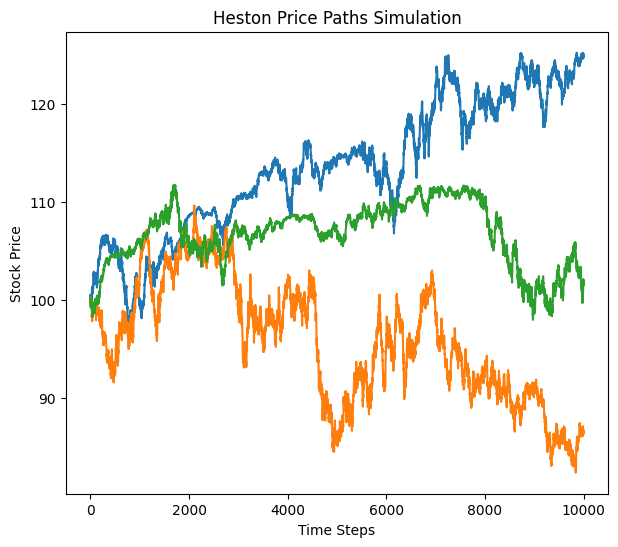

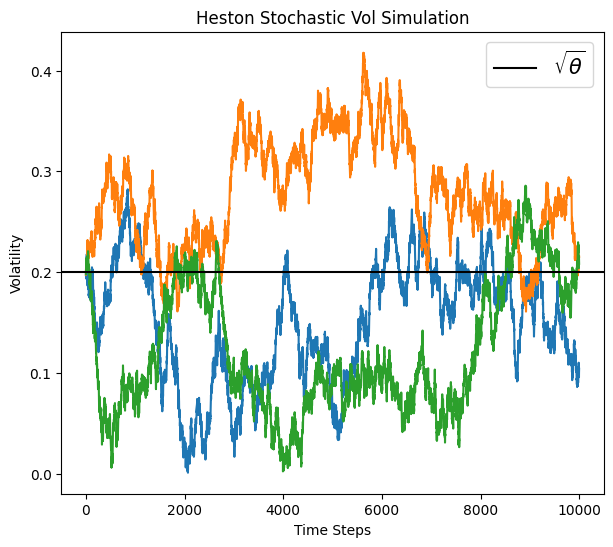

In [8]:
kappa =3
theta = 0.04
v_0 =  0.04
xi = 0.6
r = 0.05
S = 100
paths =3
steps = 10000
T = 1
rho = -0.8
prices,sigs = generate_heston_paths(S, T, r, kappa, theta,
                                    v_0, rho, xi, steps, paths,
                                    return_vol=True)        
    
plt.figure(figsize=(7,6))
plt.plot(prices.T)
plt.title('Heston Price Paths Simulation')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.show()

plt.figure(figsize=(7,6))
plt.plot(np.sqrt(sigs).T)
plt.axhline(np.sqrt(theta), color='black', label=r'$\sqrt{\theta}$')
plt.title('Heston Stochastic Vol Simulation')
plt.xlabel('Time Steps')
plt.ylabel('Volatility')
plt.legend(fontsize=15)
plt.show()

NameError: name 'implied_vol' is not defined

# 2. Let's price using the strikes (use BS to get prices)

# 3 (Bonus). Let's build the volatility surface: 

In [ ]:
# 1.